# XAI Evaluation Results Analysis
This notebook analyzes the XAI pipeline evaluation results and visualizes the performance across different models, explainers, thresholding techniques, and bounding box methods.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Define paths
RESULTS_DIR = '.'
FINAL_RESULTS_PATH = f'{RESULTS_DIR}/final_test_results.csv'
VAL_COMBO_PATH = f'{RESULTS_DIR}/validation_combo_results.csv'
BEST_PIPELINES_PATH = f'{RESULTS_DIR}/best_pipelines.json'


## 1. Validation Results Analysis (Thresholds & BBox Methods)
Here we plot the bounding box IoU for each Model+Explainer combinations. The x-axis represents the Threshold method, the y-axis is the BBox IoU, and the colors represent the BBox extraction method.


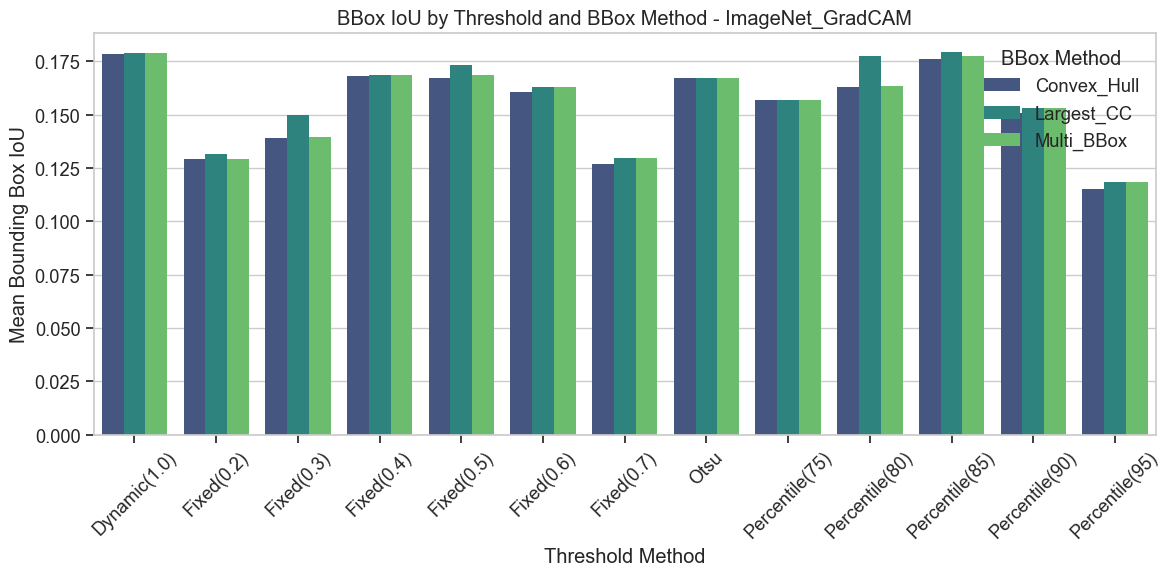

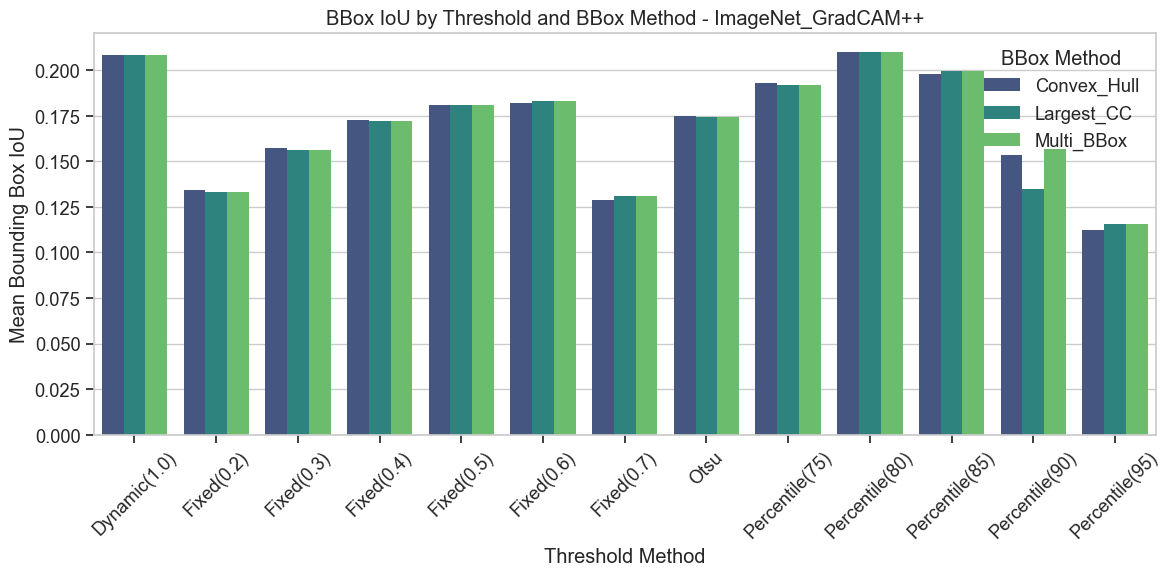

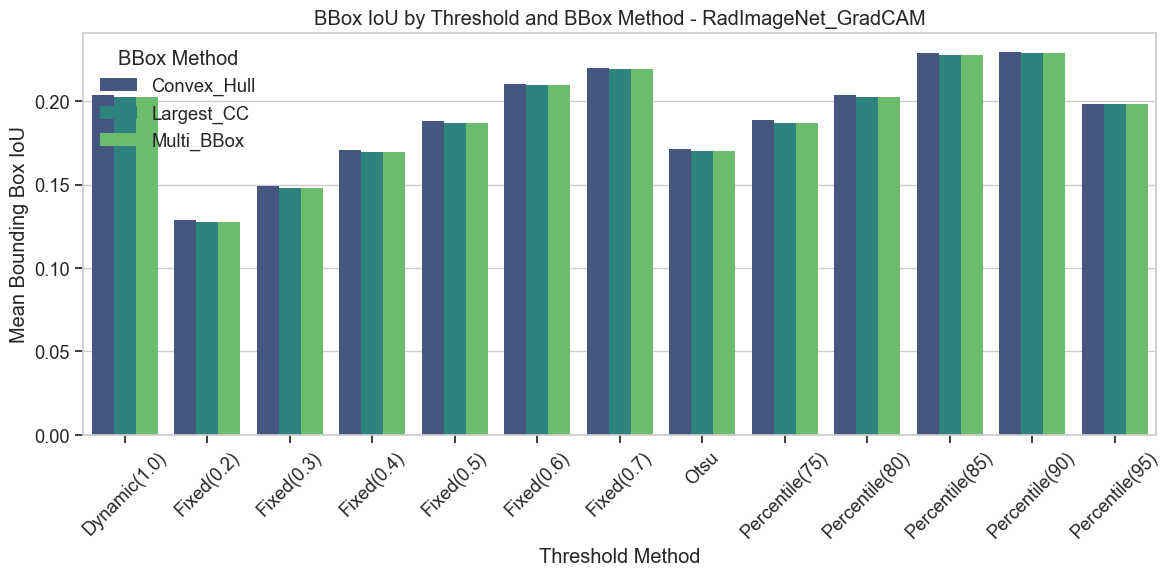

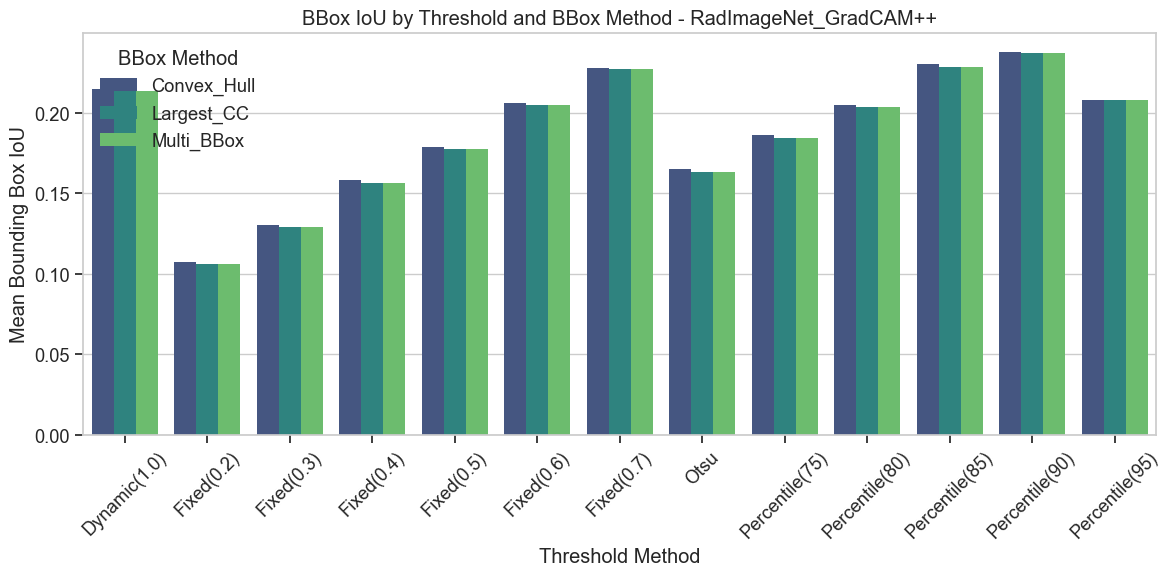

In [2]:
# Load validation combo results
val_df = pd.read_csv(VAL_COMBO_PATH)

# The 'engine' column contains both model and explainer (e.g., ImageNet_GradCAM)
engines = val_df['engine'].unique()

# Calculate mean IoU for each combination
agg_df = val_df.groupby(['engine', 'threshold', 'bbox_method'])['bbox_iou'].mean().reset_index()

for engine in engines:
    engine_df = agg_df[agg_df['engine'] == engine]
    
    plt.figure(figsize=(12, 6))
    
    # Create grouped bar chart
    sns.barplot(data=engine_df, x='threshold', y='bbox_iou', hue='bbox_method', palette='viridis')
    
    plt.title(f'BBox IoU by Threshold and BBox Method - {engine}')
    plt.xlabel('Threshold Method')
    plt.ylabel('Mean Bounding Box IoU')
    plt.xticks(rotation=45)
    plt.legend(title='BBox Method')
    plt.tight_layout()
    plt.show()


## 2. Best Pipelines Overview
Summary of the best pipelines chosen from the validation phase.


In [3]:
with open(BEST_PIPELINES_PATH, 'r') as f:
    best_pipelines = json.load(f)

best_df = pd.DataFrame(best_pipelines).T
display(best_df)


,threshold,bbox_method,val_bbox_iou,val_pixel_iou,val_point_game,val_recall,val_area_ratio
ImageNet_GradCAM,Percentile(85),Largest_CC,0.179544,0.098024,0.175214,0.574879,0.214246
ImageNet_GradCAM++,Percentile(80),Convex_Hull,0.210143,0.137332,0.094017,0.821306,0.302771
RadImageNet_GradCAM,Percentile(90),Convex_Hull,0.229715,0.147355,0.181624,0.546392,0.145617
RadImageNet_GradCAM++,Percentile(90),Convex_Hull,0.238057,0.15928,0.279915,0.533629,0.136218


## 3. Final Test Set Results
Comparing the top pipelines on the unseen test set.


C:\Users\LOQ\AppData\Local\Temp\ipykernel_17404\1324473686.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_agg, x='engine', y='bbox_iou', palette='Set2')


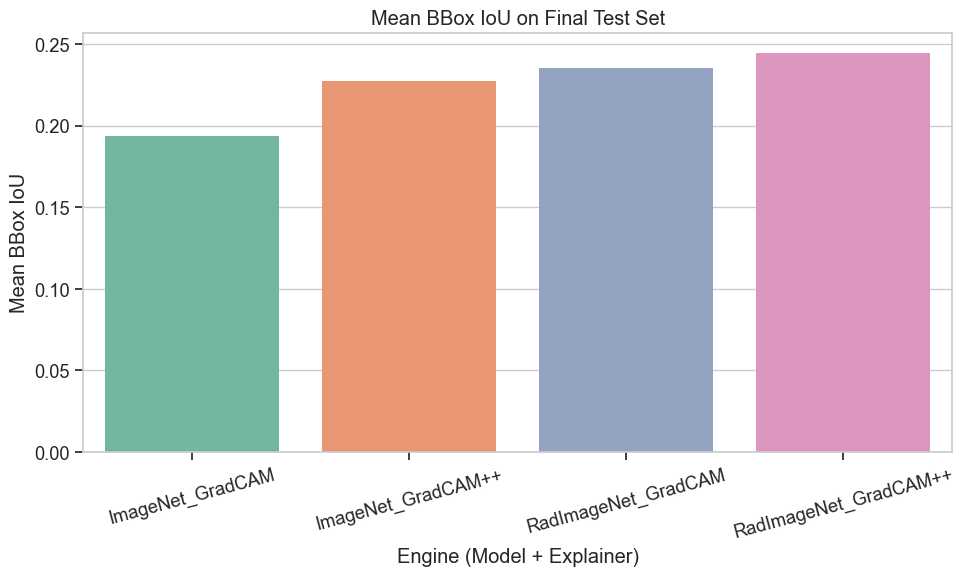

,engine,bbox_iou,pixel_iou,point_game,recall,area_ratio
0,ImageNet_GradCAM,0.193571,0.102317,0.189401,0.567511,0.214809
1,ImageNet_GradCAM++,0.227094,0.140858,0.125613,0.801449,0.304551
2,RadImageNet_GradCAM,0.235279,0.151477,0.190383,0.523474,0.144232
3,RadImageNet_GradCAM++,0.244736,0.163369,0.308145,0.522104,0.136009


In [4]:
# Load final test results
test_df = pd.read_csv(FINAL_RESULTS_PATH)

# Aggregate test results by engine
test_agg = test_df.groupby('engine').agg({
    'bbox_iou': 'mean',
    'pixel_iou': 'mean',
    'point_game': 'mean',
    'recall': 'mean',
    'area_ratio': 'mean'
}).reset_index()

# Plot BBox IoU on Test Set
plt.figure(figsize=(10, 6))
sns.barplot(data=test_agg, x='engine', y='bbox_iou', palette='Set2')
plt.title('Mean BBox IoU on Final Test Set')
plt.xlabel('Engine (Model + Explainer)')
plt.ylabel('Mean BBox IoU')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

display(test_agg)


STAGE 6: Comprehensive Visual Analysis Dashboard


C:\Users\LOQ\AppData\Local\Temp\ipykernel_14140\2768617872.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
C:\Users\LOQ\AppData\Local\Temp\ipykernel_14140\2768617872.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45, ha='right')


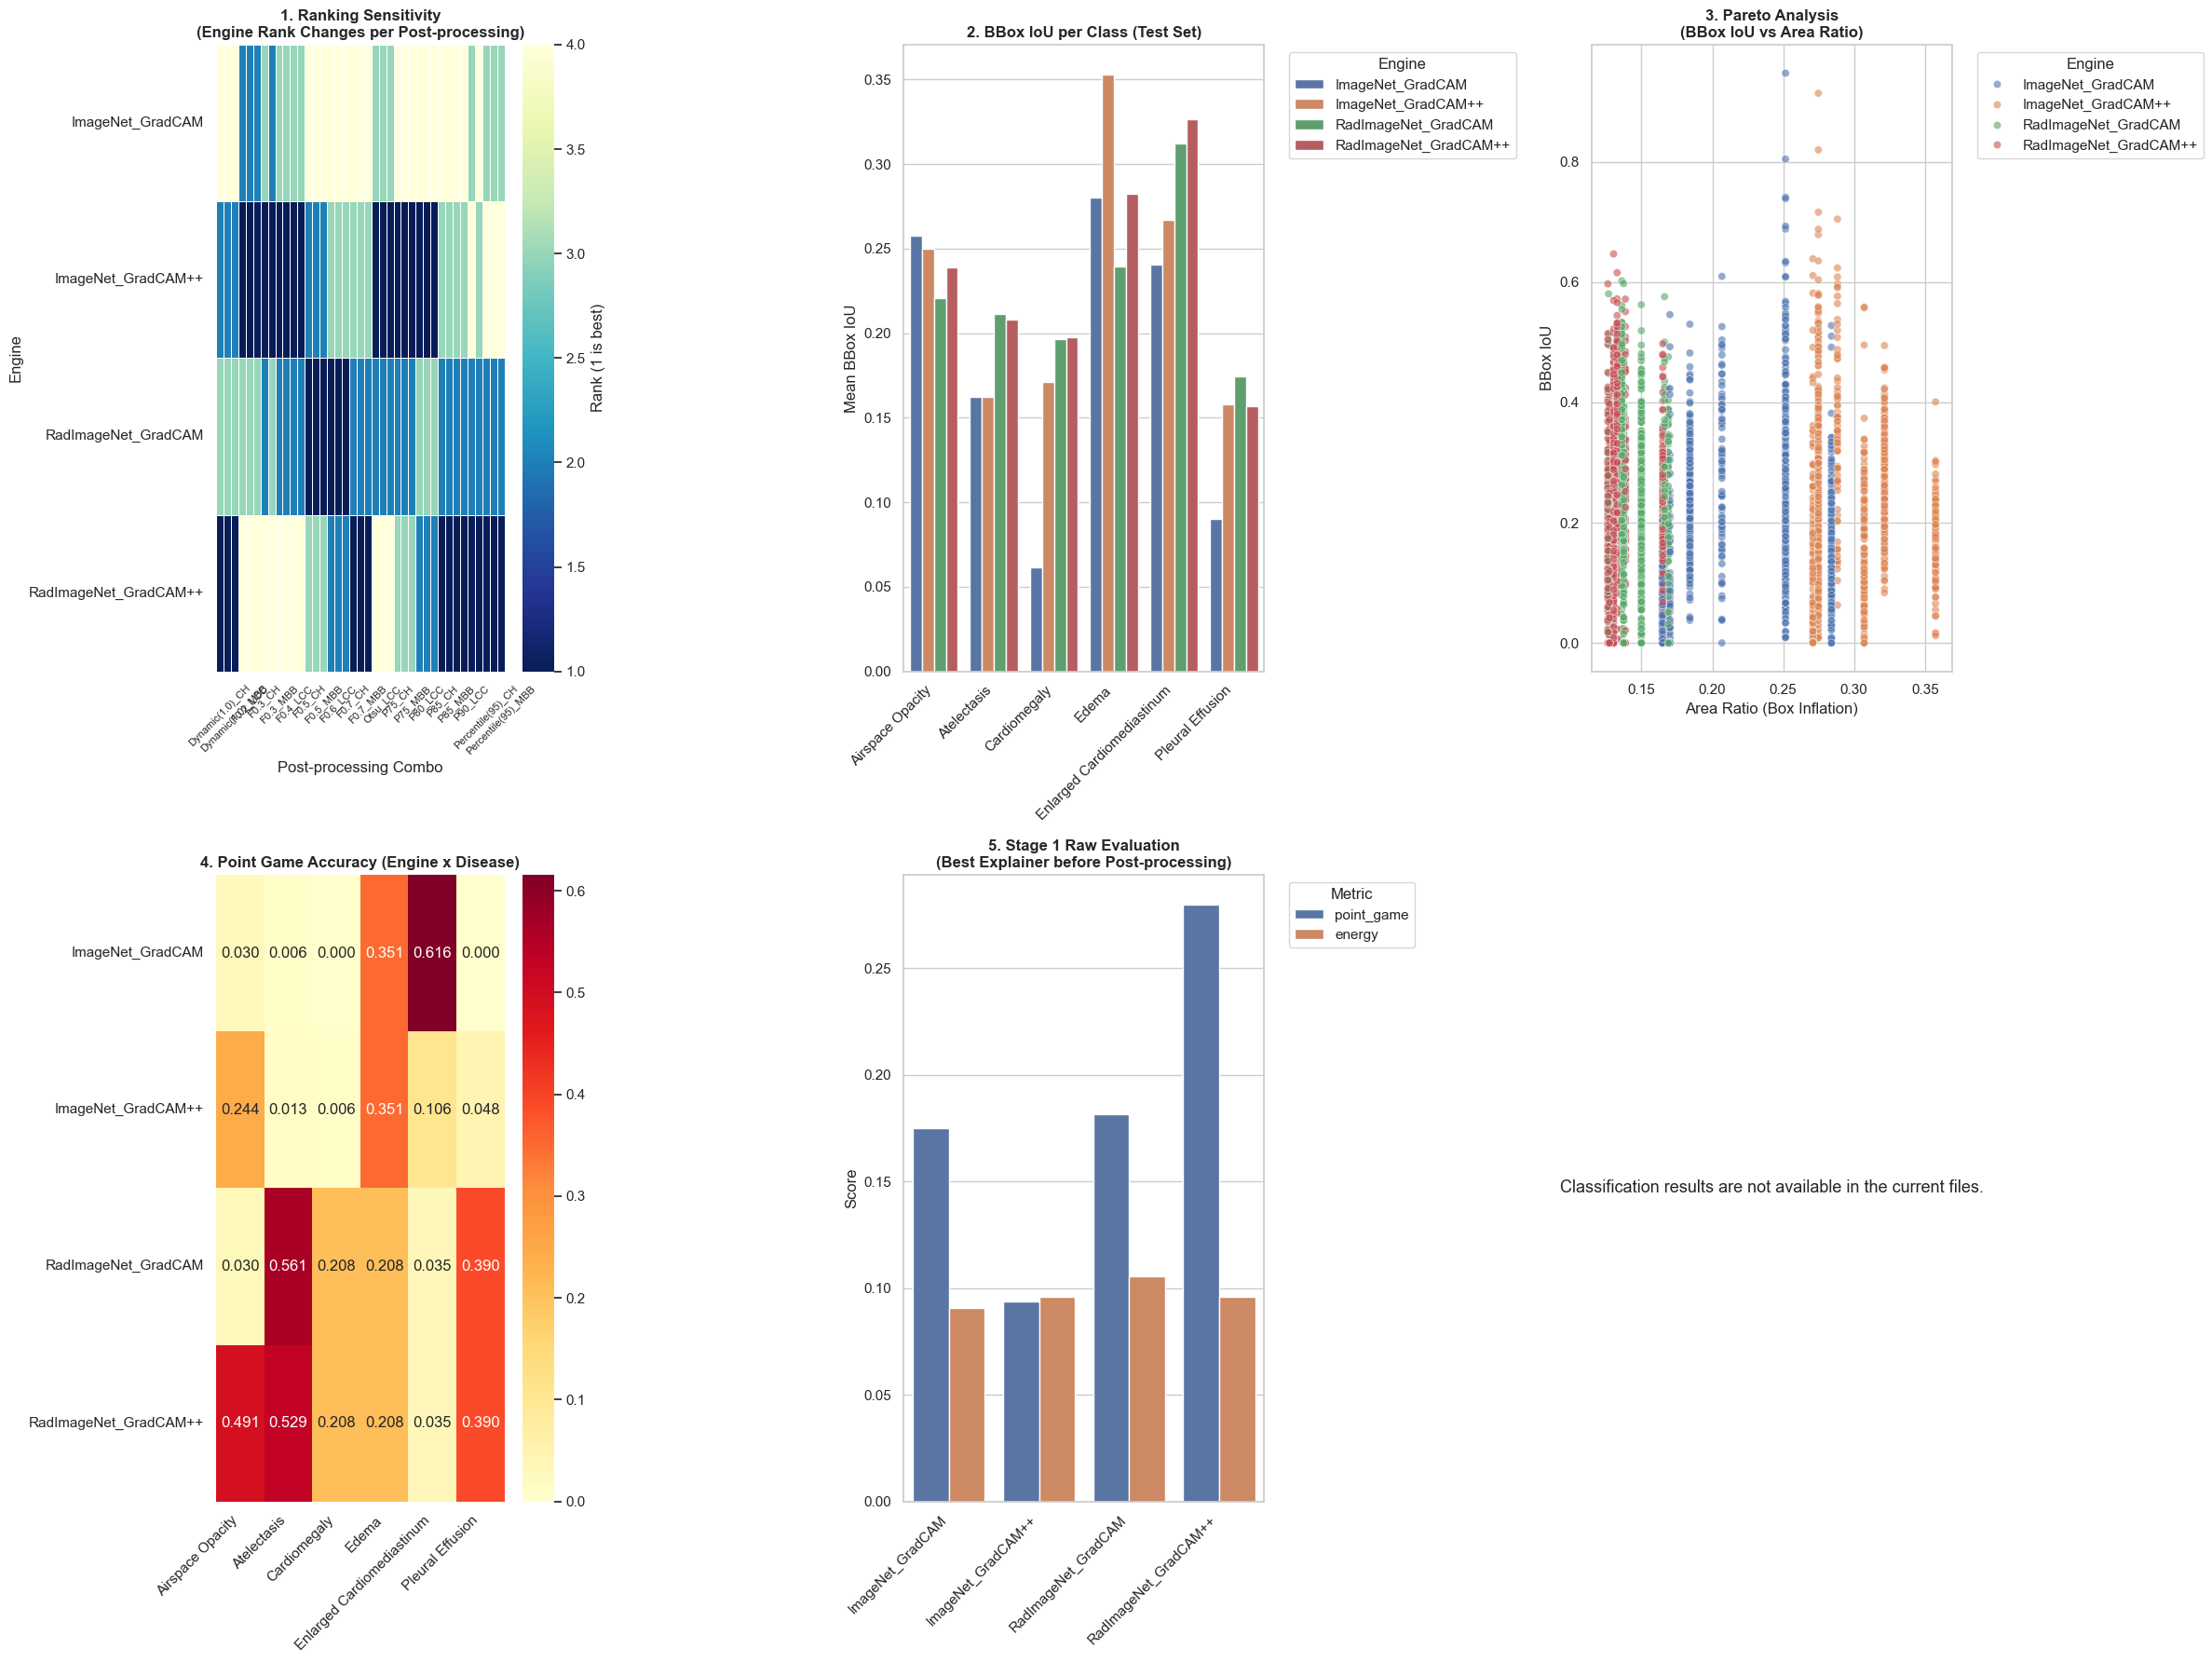

In [5]:
print('=' * 70)
print('STAGE 6: Comprehensive Visual Analysis Dashboard')
print('=' * 70)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = '.'
FINAL_RESULTS_PATH = f'{RESULTS_DIR}/final_test_results.csv'
VAL_COMBO_PATH = f'{RESULTS_DIR}/validation_combo_results.csv'
RAW_EVAL_PATH = f'{RESULTS_DIR}/raw_evaluation.csv'

sns.set_theme(style='whitegrid')
fig = plt.figure(figsize=(24, 18))

import os

# Load the result tables used by the dashboard
combo_df = pd.read_csv(VAL_COMBO_PATH)
final_df = pd.read_csv(FINAL_RESULTS_PATH)
raw_df = pd.read_csv(RAW_EVAL_PATH)
class_df = pd.DataFrame()

# Normalize column names so the plots can use a consistent schema
if 'iou' in raw_df.columns and 'bbox_iou' not in raw_df.columns:
    raw_df = raw_df.rename(columns={'iou': 'bbox_iou'})
if 'iou' in final_df.columns and 'bbox_iou' not in final_df.columns:
    final_df = final_df.rename(columns={'iou': 'bbox_iou'})

# 1. Ranking Sensitivity Heatmap
ax1 = plt.subplot(2, 3, 1)
threshold_label_map = {
    'Fixed(0.2)': 'F0.2',
    'Fixed(0.3)': 'F0.3',
    'Fixed(0.4)': 'F0.4',
    'Fixed(0.5)': 'F0.5',
    'Fixed(0.6)': 'F0.6',
    'Fixed(0.7)': 'F0.7',
    'Otsu': 'Otsu',
    'Percentile(75)': 'P75',
    'Percentile(80)': 'P80',
    'Percentile(85)': 'P85',
    'Percentile(90)': 'P90',
    'Adaptive': 'Adap',
    'Dynamic(0.1)': 'D0.1',
    'Dynamic(0.2)': 'D0.2',
    'Dynamic(0.3)': 'D0.3',
}
bbox_label_map = {'Largest_CC': 'LCC', 'Multi_BBox': 'MBB', 'Convex_Hull': 'CH'}
combo_df = combo_df.copy()
combo_df['combo'] = combo_df['threshold'].map(lambda value: threshold_label_map.get(value, value)) + '_' + combo_df['bbox_method'].map(lambda value: bbox_label_map.get(value, value))
pivot_combo = combo_df.pivot_table(index='engine', columns='combo', values='bbox_iou', aggfunc='mean')
rank_df = pivot_combo.rank(ascending=False, method='min', axis=0)
rank_df = rank_df.loc[:, rank_df.mean(axis=0).sort_values().index]
show_annots = rank_df.shape[1] <= 8
sns.heatmap(rank_df, annot=show_annots, fmt='.0f' if show_annots else '', linewidths=0.4, linecolor='white', cmap='YlGnBu_r', cbar_kws={'label': 'Rank (1 is best)'}, ax=ax1)
ax1.set_title("1. Ranking Sensitivity\n(Engine Rank Changes per Post-processing)", fontweight='bold')
ax1.set_xlabel("Post-processing Combo")
ax1.set_ylabel("Engine")
ax1.tick_params(axis='x', labelrotation=45, labelsize=8)

# 2. Grouped Bar Chart for BBox IoU per class
ax2 = plt.subplot(2, 3, 2)
disease_iou = final_df.groupby(['disease', 'engine'])['bbox_iou'].mean().reset_index()
sns.barplot(data=disease_iou, x='disease', y='bbox_iou', hue='engine', ax=ax2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_title("2. BBox IoU per Class (Test Set)", fontweight='bold')
ax2.set_ylabel("Mean BBox IoU")
ax2.set_xlabel("")
ax2.legend(title='Engine', bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. Pareto Analysis (BBox IoU vs Area Ratio)
ax3 = plt.subplot(2, 3, 3)
sns.scatterplot(data=final_df, x='area_ratio', y='bbox_iou', hue='engine', alpha=0.6, ax=ax3)
ax3.set_title("3. Pareto Analysis\n(BBox IoU vs Area Ratio)", fontweight='bold')
ax3.set_xlabel("Area Ratio (Box Inflation)")
ax3.set_ylabel("BBox IoU")
ax3.legend(title='Engine', bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Heatmap Matrix for Point Game
ax4 = plt.subplot(2, 3, 4)
pg_pivot = final_df.pivot_table(index='engine', columns='disease', values='point_game', aggfunc='mean')
sns.heatmap(pg_pivot, annot=True, cmap='YlOrRd', fmt='.3f', ax=ax4)
ax4.set_title("4. Point Game Accuracy (Engine x Disease)", fontweight='bold')
ax4.set_xlabel("")
ax4.set_ylabel("")
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')

# 5. Stage 1 Raw Evaluation
ax5 = plt.subplot(2, 3, 5)
raw_summary = raw_df.groupby('engine')[['point_game', 'energy']].mean().reset_index()
raw_melted = raw_summary.melt(id_vars='engine', var_name='Metric', value_name='Score')
sns.barplot(data=raw_melted, x='engine', y='Score', hue='Metric', ax=ax5)
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45, ha='right')
ax5.set_title("5. Stage 1 Raw Evaluation\n(Best Explainer before Post-processing)", fontweight='bold')
ax5.set_xlabel("")
ax5.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. Classification Performance (AUROC & mAP)
ax6 = plt.subplot(2, 3, 6)
required_class_cols = {'disease', 'AUROC_ImageNet', 'AUROC_RadImageNet', 'mAP_ImageNet', 'mAP_RadImageNet'}
if required_class_cols.issubset(class_df.columns):
    class_melted = class_df.melt(id_vars='disease', value_vars=['AUROC_ImageNet', 'AUROC_RadImageNet', 'mAP_ImageNet', 'mAP_RadImageNet'], 
                                 var_name='Metric_Model', value_name='Score')
    sns.barplot(data=class_melted, x='disease', y='Score', hue='Metric_Model', ax=ax6)
    ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right')
    ax6.set_title("6. Classification Performance\n(AUROC & mAP per Class)", fontweight='bold')
    ax6.set_xlabel("")
    ax6.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    ax6.axis('off')
    ax6.text(0.5, 0.5, 'Classification results are not available in the current files.', ha='center', va='center', fontsize=13)

plt.tight_layout()
os.makedirs('./xai_results', exist_ok=True)
plt.savefig('./xai_results/comprehensive_analysis_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
